# GRU (Gated Recurrent Unit)

## Definition
GRU (Gated Recurrent Unit), introduced by Cho et al. (2014), is a simplified variant of LSTM that uses only two gates — Reset and Update — and a single hidden state, eliminating the separate cell state. GRUs achieve similar performance to LSTMs on many tasks while being computationally more efficient due to fewer parameters and a simpler architecture.

## Why It Is Needed
- **Computational Efficiency:** GRUs have fewer parameters than LSTMs, making them faster to train and less prone to overfitting on smaller datasets.
- **Simplified Gating:** Two gates instead of three provide a simpler but still effective mechanism for capturing long-range dependencies.
- **Comparable Performance:** GRUs perform comparably to LSTMs on many NLP tasks, making them a practical, lighter alternative.

## Real-World Applications
- Text classification and sentiment analysis on medium-length sequences
- Speech synthesis and audio sequence modelling
- Machine translation in resource-constrained environments
- Time-series forecasting
- Mobile and edge NLP applications where model size matters

## Important Points
- **Two Gates:**
  - **Update Gate (`zₜ`):** Controls how much of the past hidden state to carry forward.
    - `zₜ = σ(Wz · [hₜ₋₁, xₜ])`
  - **Reset Gate (`rₜ`):** Controls how much of the past hidden state to forget when computing the candidate.
    - `rₜ = σ(Wr · [hₜ₋₁, xₜ])`
- **Candidate Hidden State:** `h̃ₜ = tanh(W · [rₜ ⊙ hₜ₋₁, xₜ])`
- **Final Hidden State:** `hₜ = (1 − zₜ) ⊙ hₜ₋₁ + zₜ ⊙ h̃ₜ`
- **GRU vs LSTM:**

| Feature | GRU | LSTM |
|---|---|---|
| Gates | 2 (Reset, Update) | 3 (Forget, Input, Output) |
| States | 1 (hidden state) | 2 (hidden + cell state) |
| Parameters | Fewer | More |
| Speed | Faster | Slower |
| Performance | Comparable | Slightly better on complex tasks |

## Visual Understanding
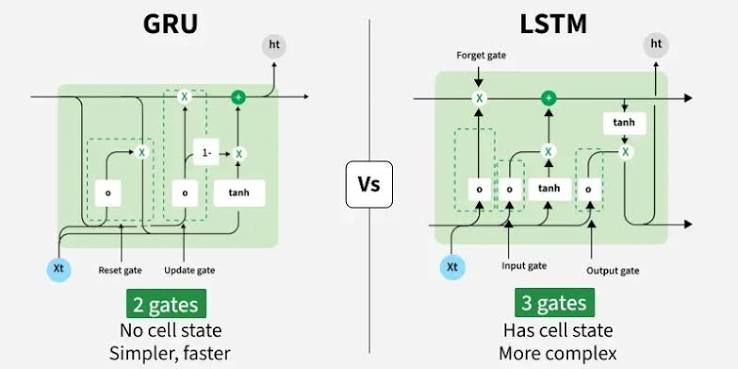

## Implementation
Practical implementation will be added here.

## Key Takeaways
- GRU is a streamlined version of LSTM with two gates and a single hidden state.
- The Update gate replaces both the Forget and Input gates of LSTM.
- GRUs train faster and use fewer parameters than LSTMs.
- For most practical NLP tasks, GRU and LSTM deliver comparable performance.
- GRU is preferred when speed, simplicity, or smaller dataset size is a constraint.

## Text Classification

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample dataset
texts = ['I loved this movie!', 'It was a terrible movie.']
labels = np.array([1, 0])  # <-- Convert to NumPy array

# Tokenize
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
X = tokenizer.texts_to_sequences(texts)
X = pad_sequences(X, padding='post')

# Build model
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=128, input_length=X.shape[1]))
model.add(GRU(units=64))
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
model.fit(X, labels, epochs=5)

# Predict new review
new_review = ["I hated the movie."]
new_review_seq = tokenizer.texts_to_sequences(new_review)
new_review_seq = pad_sequences(new_review_seq, padding='post', maxlen=X.shape[1])
prediction = model.predict(new_review_seq)
print("Sentiment:", "Positive" if prediction[0][0] > 0.5 else "Negative")

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.6934
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.6825
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 1.0000 - loss: 0.6715
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.6604
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.6490
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
Sentiment: Positive


## NER

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense, TimeDistributed
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample sentence and labels
texts = [['Barack', 'Obama', 'was', 'born', 'in', 'Hawaii']]
labels = [['B-PER', 'I-PER', 'O', 'O', 'O', 'B-LOC']]

# Tokenize text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
X = tokenizer.texts_to_sequences(texts)
X = pad_sequences(X, padding='post')

# Label mapping
label_map = {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-LOC': 3}
Y = [[label_map[label] for label in sent] for sent in labels]
Y = pad_sequences(Y, padding='post')  # Ensure same shape
Y = np.expand_dims(Y, -1)  # Shape should be (batch_size, sequence_len, 1)

# Build model
model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=128, input_length=X.shape[1]))
model.add(GRU(units=64, return_sequences=True))
model.add(Dropout(0.1))
model.add(TimeDistributed(Dense(len(label_map), activation='softmax')))

# Compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(X, Y, epochs=5)

# Predict on new sentence
new_sentence = ['Obama', 'visited', 'Germany']
new_sentence_seq = tokenizer.texts_to_sequences([new_sentence])
new_sentence_seq = pad_sequences(new_sentence_seq, padding='post', maxlen=X.shape[1])
predictions = model.predict(new_sentence_seq)

# Convert predictions to label names
predicted_labels = [list(label_map.keys())[np.argmax(pred)] for pred in predictions[0][:len(new_sentence)]]
print("Entities:", list(zip(new_sentence, predicted_labels)))

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.1667 - loss: 1.3966
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0000e+00 - loss: 1.3854
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6667 - loss: 1.3682
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6667 - loss: 1.3409
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 1.3252
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
Entities: [('Obama', 'O'), ('visited', 'O'), ('Germany', 'O')]
